In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

nb_dir = os.path.split(os.getcwd())[0]
if nb_dir not in sys.path:
    sys.path.append(nb_dir)
import warnings

warnings.filterwarnings("ignore")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import yfinance as yf
import numpy_financial as npf

In [3]:
PREDICT_BY_YEAR = False
PREDICT_YEARS = 4
REBALANCE_MONTHS = 12

In [4]:
df_income = pd.read_csv("../data/income_statement.csv")
df_income = df_income[df_income["period"] == "Quarter"]

df_assets = pd.read_csv("../data/balance_sheet_assets.csv")
df_assets = df_assets[df_assets["period"] == "Quarter"]
df_assets["cash_and_equivalents"] /= 1_000_000

df_liabilities = pd.read_csv("../data/balance_sheet_liabilities.csv")
df_liabilities = df_liabilities[df_liabilities["period"] == "Quarter"]
df_liabilities["long_term_debt"] /= 1_000_000
df_liabilities["minority_interest"] /= 1_000_000

sp500 = pd.read_csv("../data/sp500_members.csv")
df_sp500 = df_income[df_income["act_symbol"].isin(sp500["Symbol"])]
df_sp500["net_income"] /= 1_000_000
df_sp500["average_shares"] /= 1_000_000
df_sp500

,act_symbol,date,period,sales,cost_of_goods,gross_profit,selling_administrative_depreciation_amortization_expenses,income_after_depreciation_and_amortization,non_operating_income,interest_expense,...,investment_gains,other_income,income_from_continuing_operations,extras_and_discontinued_operations,net_income,income_before_depreciation_and_amortization,depreciation_and_amortization,average_shares,diluted_eps_before_non_recurring_items,diluted_net_eps
4,A,2016-07-31,Quarter,1044000000,502000000,542000000,396000000,146000000,5000000,17000000,...,0,0,124000000,0,124.0,NaN,NaN,328.0,0.49,0.38
5,A,2016-10-31,Quarter,1111000000,523000000,588000000,405000000,183000000,-13000000,19000000,...,0,0,124000000,0,124.0,NaN,NaN,328.0,0.59,0.37
7,A,2017-01-31,Quarter,1067000000,493000000,574000000,368000000,206000000,7000000,20000000,...,0,0,168000000,0,168.0,NaN,NaN,326.0,0.53,0.52
8,A,2017-04-30,Quarter,1102000000,510000000,592000000,391000000,201000000,10000000,20000000,...,0,0,164000000,0,164.0,NaN,NaN,325.0,0.58,0.50
9,A,2017-07-31,Quarter,1114000000,518000000,596000000,395000000,201000000,11000000,19000000,...,0,0,175000000,0,175.0,NaN,NaN,326.0,0.59,0.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198974,ZTS,2023-06-30,Quarter,2180000000,607000000,1573000000,643000000,930000000,0,58000000,...,0,0,670000000,0,671.0,NaN,NaN,462.9,1.41,1.45
198975,ZTS,2023-09-30,Quarter,2151000000,638000000,1513000000,737000000,776000000,0,59000000,...,0,0,596000000,0,596.0,NaN,NaN,461.4,1.36,1.29
198976,ZTS,2023-12-31,Quarter,2213000000,728000000,1485000000,776000000,709000000,0,59000000,...,0,0,523000000,0,525.0,NaN,NaN,460.1,1.24,1.14
198978,ZTS,2024-03-31,Quarter,2190000000,643000000,1547000000,742000000,805000000,0,58000000,...,0,0,599000000,0,599.0,NaN,NaN,458.8,1.38,1.31


In [5]:
def adf_deg(end_date, verbose=False):
    ticker_to_deg = {}
    df_fdmt = df_sp500[df_sp500["date"] < end_date]

    for tkr in df_fdmt["act_symbol"].drop_duplicates():
        net_income = df_fdmt[df_fdmt["act_symbol"] == tkr]["net_income"].dropna()
        net_income_diff = net_income
        if net_income.size >= 12:
            degree = 0
            test = sm.tsa.stattools.adfuller(net_income)
            while test[1] > 0.001 and degree < 3:
                net_income_diff = net_income_diff.diff().fillna(0)
                test = sm.tsa.stattools.adfuller(net_income_diff)
                degree += 1
            if degree == 3 and verbose:
                print(f"Ticker {tkr} is likely not stationary")
            else:
                ticker_to_deg[tkr] = degree
    return ticker_to_deg

In [6]:
def forecast(tkr_to_deg, verbose=False):
    tkr_to_forecast = {}
    for tkr in tkr_to_deg:
        deg = tkr_to_deg[tkr]
        net_income = (
            df_sp500[df_sp500["act_symbol"] == tkr]["net_income"]
            .fillna(0)
            .astype(np.float64)
        )
        endog = net_income
        for _ in range(deg):
            endog = endog.diff().fillna(0)

        mod = sm.tsa.ARIMA(
            endog, order=(0, max(deg, 1), 1), seasonal_order=(0, max(deg, 1), 1, 4)
        )
        res = mod.fit()

        n_predictions = PREDICT_YEARS * 4
        if deg == 0:
            tkr_to_forecast[tkr] = (
                pd.Series(np.r_[net_income.to_numpy(), res.predict(n_predictions)]),
                res.aic,
            )
        else:
            predict_val = np.r_[
                net_income.iloc[:deg], endog.iloc[deg:], res.predict(n_predictions)
            ]
            tkr_to_forecast[tkr] = (
                pd.Series(
                    np.r_[
                        net_income.to_numpy(),
                        np.array(predict_val).cumsum()[-n_predictions:],
                    ]
                ),
                res.aic,
            )
        if verbose:
            print(tkr, res.aic, res.bic)
    return tkr_to_forecast

In [7]:
def predict(tkr_to_forecast, close_data, start_date):
    all_aic = pd.Series([tkr_to_forecast[tkr][1] for tkr in tkr_to_forecast])
    all_aic.describe()

    prediction = {}
    for tkr in tkr_to_forecast:
        fc, aic = tkr_to_forecast[tkr]
        cash_flow = [
            sum(fc[-4 * PREDICT_YEARS :][i * 4 : (i + 1) * 4])
            for i in range(PREDICT_YEARS)
        ]
        if (
            not df_assets[df_assets["act_symbol"] == tkr].empty
            and not df_liabilities[df_liabilities["act_symbol"] == tkr].empty
        ):
            cash = float(
                df_assets[df_assets["act_symbol"] == tkr]["cash_and_equivalents"].iloc[
                    -1
                ]
            )
            debt = float(
                df_liabilities[df_liabilities["act_symbol"] == tkr][
                    "long_term_debt"
                ].iloc[-1]
            ) + float(
                df_liabilities[df_liabilities["act_symbol"] == tkr][
                    "minority_interest"
                ].iloc[-1]
            )
            shares = float(
                df_sp500[df_sp500["act_symbol"] == tkr]["average_shares"].iloc[-1]
            )
            price = close_data.Close.loc[start_date, tkr]
            if aic < all_aic.mean():
                discount_rate = 0.08
                terminal_rate = 0.05
                maturity = (
                    (cash_flow[-1] * (1 + terminal_rate))
                    / (discount_rate - terminal_rate)
                ) / np.pow((1 + discount_rate), PREDICT_YEARS)
                val = (
                    npf.npv(discount_rate, np.append(0, cash_flow))
                    + maturity
                    + cash
                    - debt
                )
                est_price = val / shares
                prediction[tkr] = {
                    "price": price,
                    "est_price": est_price,
                    "npv": npf.npv(discount_rate, np.append(0, cash_flow)),
                    "cash": cash,
                    "debt": debt,
                    "shares": shares,
                }
    return prediction

In [8]:
close_data = yf.Tickers(list(df_sp500["act_symbol"].unique())).history(
    start="2020-01-01"
)

[*********************100%***********************]  501 of 501 completed

3 Failed downloads:
['FLT', 'PXD', 'WRK']: YFPricesMissingError('$%ticker%: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-10-29) (Yahoo error = "No data found, symbol may be delisted")')


In [9]:
start_date = close_data.Close.index[0]

In [10]:
date = start_date
predictions = {}
while date < pd.to_datetime("2024-06-01").tz_localize("UTC"):
    tkr_to_deg = adf_deg(str(date)[:10])
    tkr_to_forecast = forecast(tkr_to_deg)
    while date not in close_data.Close.index:
        date += pd.DateOffset(days=1)
    predictions[date] = predict(tkr_to_forecast, close_data, date)
    date += pd.DateOffset(months=REBALANCE_MONTHS)

/home/adam/.local/share/virtualenvs/investing-sxaH0MQ6/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/adam/.local/share/virtualenvs/investing-sxaH0MQ6/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/adam/.local/share/virtualenvs/investing-sxaH0MQ6/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/adam/.local/share/v

In [21]:
from dataclasses import dataclass
from enum import Enum
from typing import List, Mapping
import numpy as np
import pandas as pd
import numpy.typing as npt


class Side(Enum):
    BUY = 1
    SELL = -1


@dataclass
class Transaction:
    date: pd.Timestamp
    symbol: str
    qty: int
    side: Side


def tx_with_price(tx: Transaction, price: np.float64):
    return {
        "date": tx.date,
        "symbol": tx.symbol,
        "qty": tx.qty,
        "price": price,
        "side": tx.side,
    }


class Portfolio:
    def __init__(self, universe: pd.Series, cash: np.float64):
        self.cash = cash
        self.symbol_to_idx = {}
        for idx, symbol in enumerate(universe):
            self.symbol_to_idx[symbol] = idx
        self.pos = np.zeros(len(self.symbol_to_idx))
        self.avg_cost = np.zeros(len(self.symbol_to_idx))

    def execute(self, tx: Transaction, price: np.float64):
        idx = self.symbol_to_idx[tx.symbol]
        cost = price * tx.qty * tx.side.value
        self.cash -= cost
        pos_new = self.pos[idx] + tx.qty * tx.side.value
        if np.sign(pos_new) == 0:
            self.avg_cost[idx] = 0
        if np.sign(self.pos[idx]) != np.sign(pos_new):
            self.avg_cost[idx] = cost
        else:
            self.avg_cost[idx] = (self.pos[idx] * self.avg_cost[idx] + cost) / pos_new
        self.pos[idx] = pos_new

    def get_pos(self) -> npt.NDArray:
        return np.concat([self.pos, [self.cash]])

    def get_mv(self) -> npt.NDArray:
        return np.multiply(self.pos, self.avg_cost)


class Result:
    def __init__(self):
        self.txns: List[Transaction] = []
        self.positions: List = []
        self.returns: List = []

    def to_df(self, index) -> Mapping[str, pd.DataFrame]:
        return {
            "transactions": pd.DataFrame(self.txns),
            "positions": pd.DataFrame(self.positions, index=index),
            "returns": pd.Series(self.returns, index=index),
        }


def calculate_return(price: pd.Series, price_last: pd.Series, pfv: npt.NDArray):
    if price_last is not None and pfv.sum() > 0:
        w = pfv / pfv.sum()
        r_inst = np.zeros_like(price)
        np.divide(price - price_last, price_last, out=r_inst, where=price_last != 0)
        return np.dot(w, r_inst)
    return 0


def backtest_from_trades(
    txns: Mapping[pd.Timestamp, List[Transaction]],
    price_data: pd.DataFrame,
    cash: np.float64,
) -> Mapping[str, pd.DataFrame]:
    universe = price_data.columns.get_level_values(1).drop_duplicates()
    pf = Portfolio(universe, cash)
    result = Result()
    last_close = None
    for date, row in price_data.iterrows():
        close = row.loc["Close"]
        for tx in txns.get(date, []):
            price = close.loc[tx.symbol]
            pf.execute(tx, price)
            result.txns.append(tx_with_price(tx, price))
        result.positions.append(pf.get_pos())
        result.returns.append(calculate_return(close, last_close, pf.get_mv()))
        last_close = close

    return result.to_df(price_data.index)


In [24]:
i = 0
r = pd.Series(0, index=close_data.Close.index)
r_long = pd.Series(0, index=close_data.Close.index)
r_short = pd.Series(0, index=close_data.Close.index)
trades = {}
for year, prediction in predictions.items():
    print(year)
    predict_df = pd.DataFrame(prediction.values(), index=prediction.keys())
    predict_df["diff"] = predict_df.est_price - predict_df.price
    predict_df["diff_pct"] = (
        predict_df.est_price - predict_df.price
    ) / predict_df.price
    predict_df["quantile"] = pd.qcut(predict_df["diff_pct"], 5, labels=False)
    predict_df = predict_df.sort_values(
        ["quantile", "diff_pct"], ascending=False
    ).dropna()

    if i == 0:
        trades[year] = []
    if i + 1 < len(predictions):
        trades[list(predictions.keys())[i + 1]] = []
    for long_tkr in list(predict_df.head(5).index):
        trades[year].append(
            Transaction(
                date=pd.Timestamp(year).to_datetime64(),
                symbol=long_tkr,
                qty=1,
                side=Side.BUY,
            )
        )
        if i + 1 < len(predictions):
            trades[list(predictions.keys())[i + 1]].append(
                Transaction(
                    date=list(predictions.keys())[i + 1],
                    symbol=long_tkr,
                    qty=1,
                    side=Side.SELL,
                )
            )
    for short_tkr in list(predict_df.tail(5).index):
        trades[year].append(
            Transaction(
                date=pd.Timestamp(year).to_datetime64(),
                symbol=short_tkr,
                qty=1,
                side=Side.SELL,
            )
        )
        if i + 1 < len(predictions):
            trades[list(predictions.keys())[i + 1]].append(
                Transaction(
                    date=list(predictions.keys())[i + 1],
                    symbol=short_tkr,
                    qty=1,
                    side=Side.BUY,
                )
            )
    i += 1

2020-01-02 00:00:00+00:00
2021-01-04 00:00:00+00:00
2022-01-04 00:00:00+00:00
2023-01-04 00:00:00+00:00
2024-01-04 00:00:00+00:00


In [39]:
bt = backtest_from_trades(trades, close_data.fillna(0), 100000)

In [43]:
r = bt["returns"] + 1
r.iloc[0] *= 1000
r.cumprod()

Date
2020-01-02 00:00:00+00:00    1000.000000
2020-01-03 00:00:00+00:00     993.679701
2020-01-06 00:00:00+00:00     995.527732
2020-01-07 00:00:00+00:00     994.365929
2020-01-08 00:00:00+00:00    1002.175522
                                ...     
2024-10-23 00:00:00+00:00    2372.847442
2024-10-24 00:00:00+00:00    2383.434263
2024-10-25 00:00:00+00:00    2377.161790
2024-10-28 00:00:00+00:00    2396.329206
2024-10-29 00:00:00+00:00    2400.617095
Length: 1215, dtype: float64

In [27]:
bench_close = yf.Ticker("SPY").history(start="2020-01-01").Close.pct_change()
bench_close.index = r.index
bench_close.name = "SPY"

Start date,2020-01-02
End date,2024-10-29
Total months,57
,Backtest
Annual return,19.917%
Cumulative returns,140.062%
Annual volatility,29.769%
Sharpe ratio,0.76
Calmar ratio,0.51
Stability,0.76
Max drawdown,-38.843%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,38.84,2020-02-20,2020-03-20,2020-08-27,136
1,33.27,2023-07-10,2023-11-09,2024-09-19,314
2,25.44,2021-11-08,2022-12-20,2023-02-02,324
3,23.90,2023-02-15,2023-03-27,2023-06-12,84
4,8.29,2021-01-20,2021-01-29,2021-02-08,14


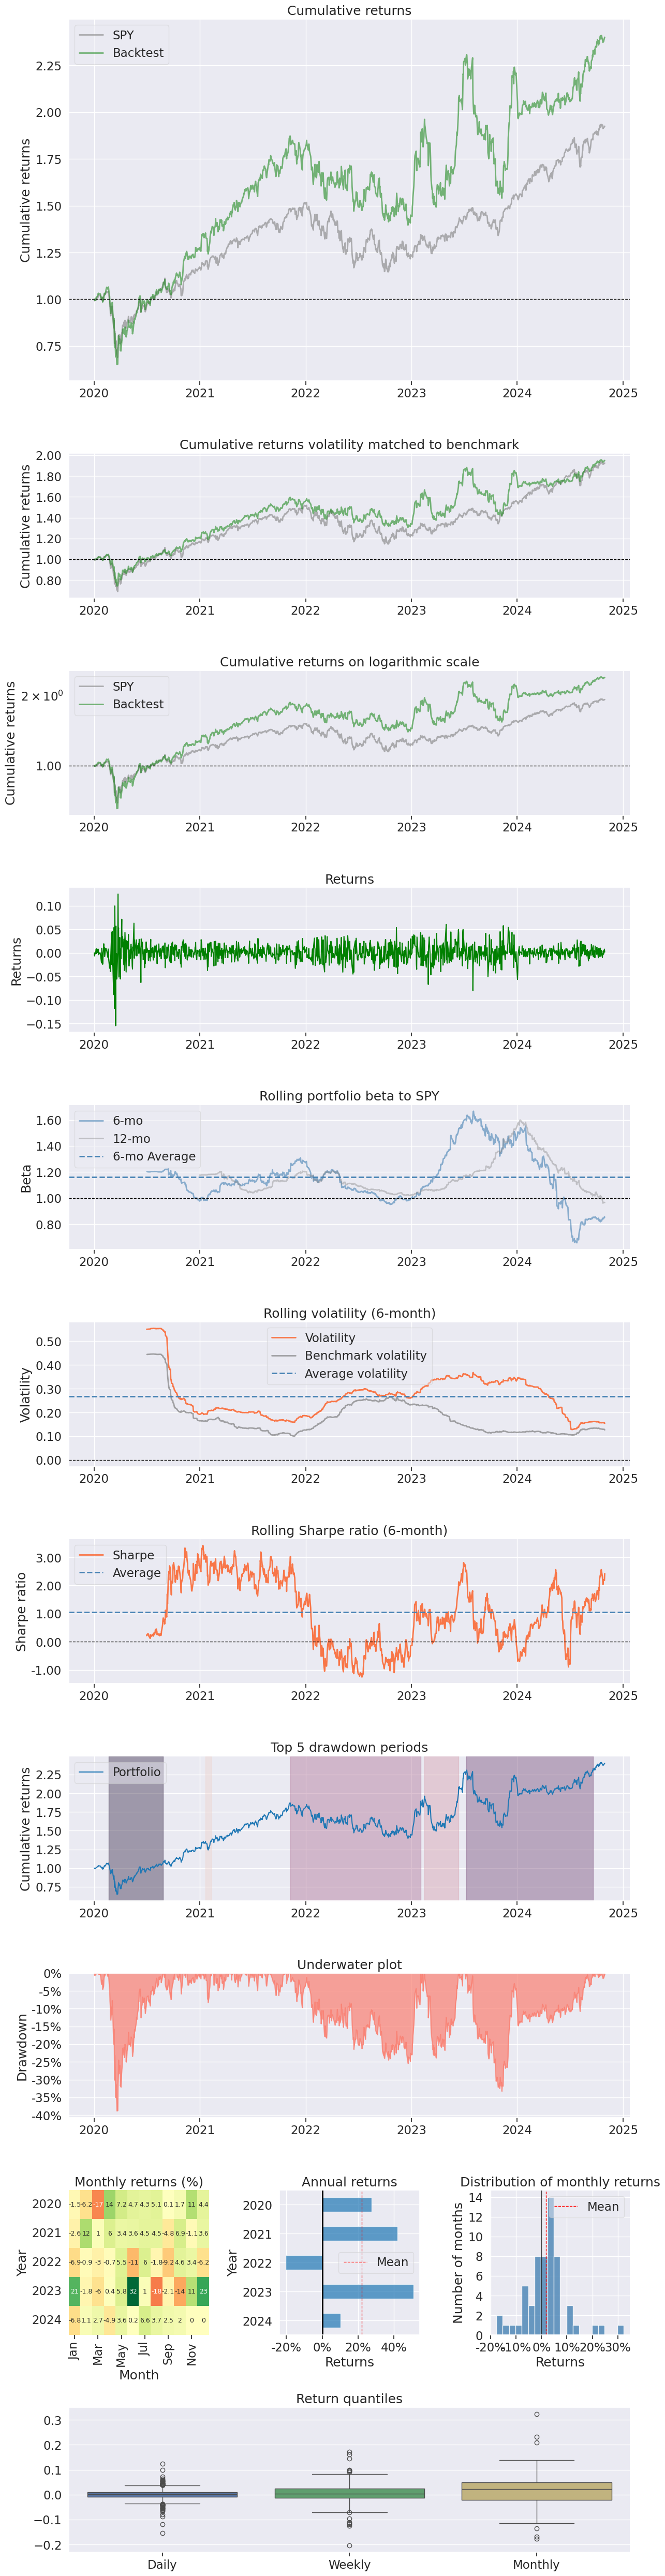

In [28]:
import pyfolio as pf


pf.create_returns_tear_sheet(bt["returns"], benchmark_rets=bench_close)

In [16]:
pf.create_returns_tear_sheet(
    r_long.loc["2020-06-01":"2024-06-01"], benchmark_rets=bench_close
)

Start date,2020-06-01
End date,2024-05-31
Total months,48
,Backtest
Annual return,0.0%
Cumulative returns,0.0%
Annual volatility,0.0%
Sharpe ratio,NaN
Calmar ratio,NaN
Stability,0.00
Max drawdown,0.0%


UFuncTypeError: Cannot cast ufunc 'multiply' output from dtype('float64') to dtype('int64') with casting rule 'same_kind'

Start date,2020-06-01
End date,2024-05-31
Total months,48
,Backtest
Annual return,6.223%
Cumulative returns,27.315%
Annual volatility,53.393%
Sharpe ratio,0.39
Calmar ratio,0.12
Stability,0.32
Max drawdown,-51.117%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,51.12,2021-01-04,2021-05-04,2022-05-11,353
1,37.69,2024-01-18,2024-02-01,NaT,NaN
2,32.62,2022-06-17,2023-02-02,2023-03-10,191
3,30.65,2023-03-23,2023-04-19,2023-05-10,35
4,17.23,2023-05-30,2024-01-05,2024-01-17,167


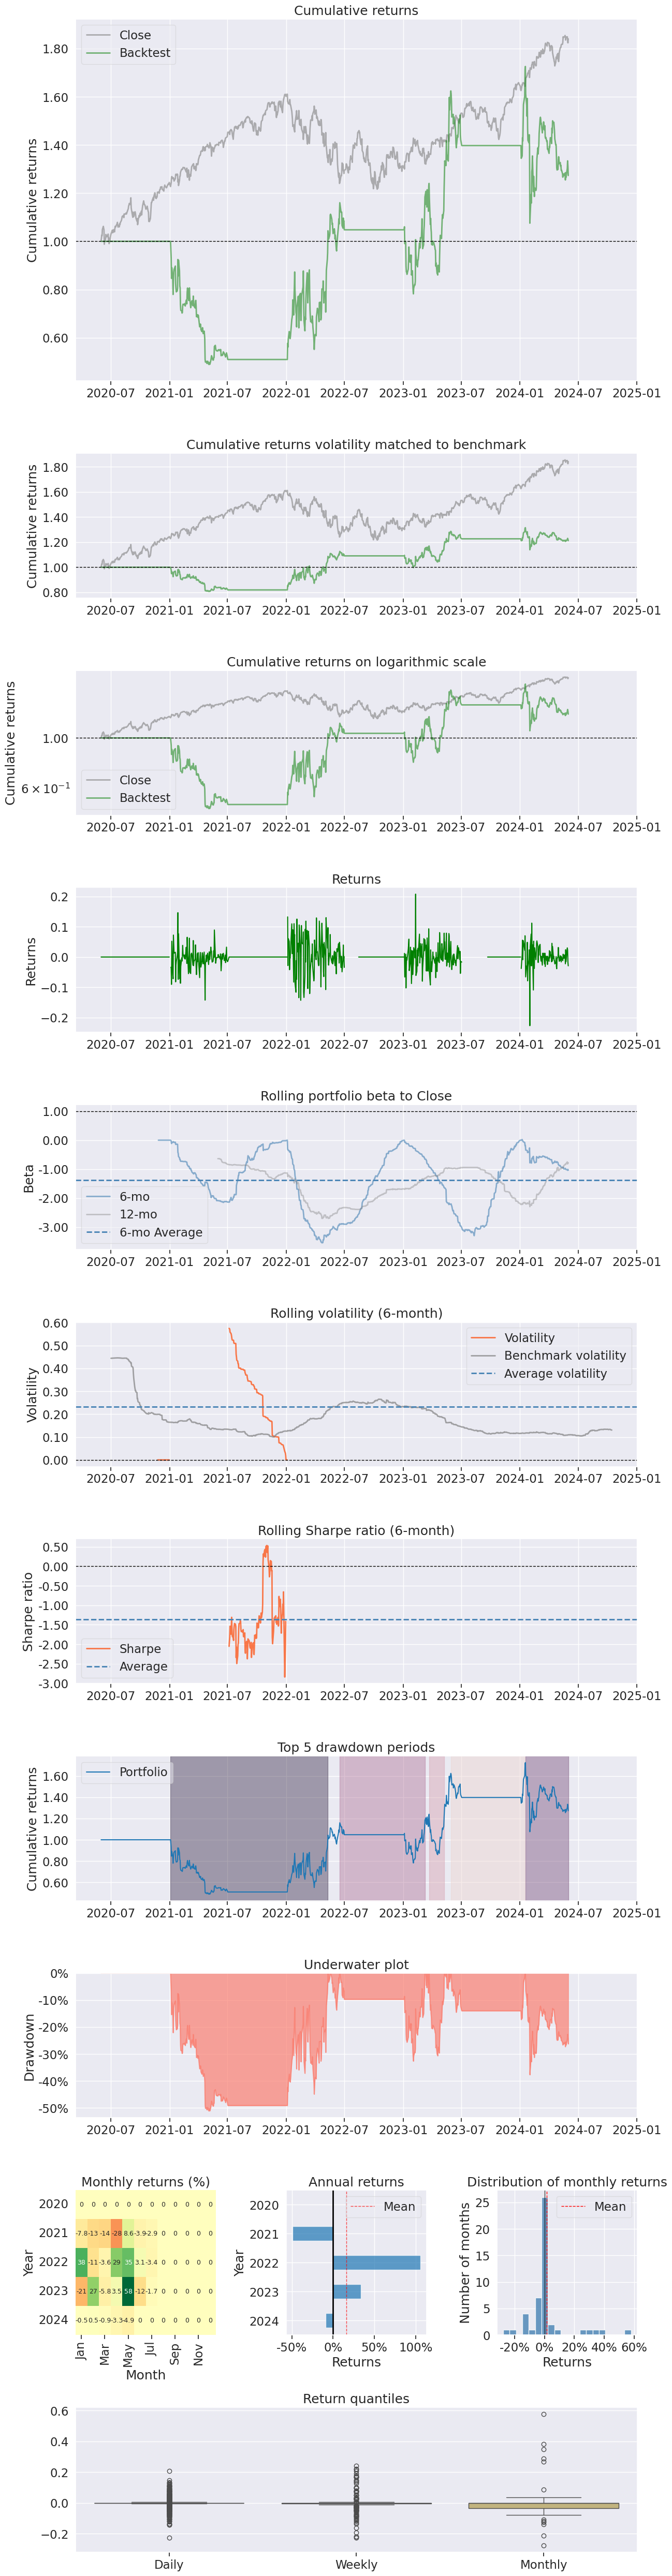

In [21]:
pf.create_returns_tear_sheet(
    r_short.loc["2020-06-01":"2024-06-01"], benchmark_rets=bench_close
)